<a href="https://colab.research.google.com/github/ibrahimymhafez/flyrank-ibrahim/blob/main/work/notebooks/w02_ml_task_framing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ibrahimymhafez/flyrank-ibrahim/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

**Lane:** Content Retention (Predicting pages at risk of traffic decay).

**Task Type:** Binary Classification.

**Why:** We are not predicting a continuous number like exact future pageviews (Regression), nor are we grouping unknown patterns (Clustering). We are trying to categorize each piece of published content into one of two distinct, actionable buckets: `At Risk (Needs Refresh)` or `Healthy (Do Not Touch)`. This binary split directly triggers the editorial team's workflow.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure plots display correctly in Colab
%matplotlib inline

# 1. Load the dataset to begin our framing
data_path = 'https://raw.github.com/ibrahimymhafez/flyrank-ibrahim/main/data/raw/content_refresh_anonymized.csv'

df = pd.read_csv(data_path)
print(f"✅ Data loaded. Ready for classification framing on {len(df)} rows.")

✅ Data loaded. Ready for classification framing on 30000 rows.


## 2. Target or proxy

**What we want to predict:** Whether a page is "At Risk" of losing its SEO value and needs an editorial refresh (Label `1`) versus a page that is "Healthy" (Label `0`).

**Where the label comes from:** Since there is no pre-existing `needs_refresh` column in the data, I must define a **proxy rule** based on observed outcomes.

I am defining "At Risk" (1) as content that has a painfully low engagement rate (< 1.0%) **AND** is actively trending downward in traffic (trend_pct < 0). If it meets both conditions, it needs intervention.

In [8]:
# 2. Create the target proxy label
engagement_threshold = 1.0

# Rule: Engagement is under 1% AND the trend is negative
df['target_needs_refresh'] = ((df['engagement_rate'] < engagement_threshold) & (df['trend_pct'] < 0)).astype(int)

print("--- Target Label Distribution ---")
distribution = df['target_needs_refresh'].value_counts(normalize=True) * 100
print(f"Healthy (0): {distribution[0]:.2f}%")
print(f"At Risk (1): {distribution[1]:.2f}%")
print("\nObservation: We have a moderately imbalanced dataset, which is typical for anomaly/risk detection.")

--- Target Label Distribution ---
Healthy (0): 53.08%
At Risk (1): 46.92%

Observation: We have a moderately imbalanced dataset, which is typical for anomaly/risk detection.


## 3. Success metric

**Chosen Metric:** Precision.

**Why:** Editorial resources are expensive. If the model says "Update this page!" (Predicts 1) but the page is actually fine (False Positive), we waste hours of a writer's time fixing something that isn't broken. High precision ensures that when the model flags a page for a refresh, we can trust that it *truly* needs it. We are willing to miss a few declining pages (lower recall) to protect the editorial team's bandwidth.

In [9]:
# 3. Establish a naive baseline to beat
from sklearn.metrics import precision_score, recall_score, classification_report

# Naive fixed rule: "Let's just update everything older than 300 days"
df['dummy_prediction'] = (df['content_age_days'] > 300).astype(int)

baseline_precision = precision_score(df['target_needs_refresh'], df['dummy_prediction'], zero_division=0)
baseline_recall = recall_score(df['target_needs_refresh'], df['dummy_prediction'], zero_division=0)

print(f"Baseline Precision (Age > 300 days): {baseline_precision:.2%}")
print("\nThis is the metric our ML model MUST beat. A precision this low means a huge amount of wasted editorial time if we just relied on content age.")

Baseline Precision (Age > 300 days): 41.36%

This is the metric our ML model MUST beat. A precision this low means a huge amount of wasted editorial time if we just relied on content age.


## 4. The unit of analysis, as a real dataframe

**Unit of Analysis:** One row equals **one unique piece of published web content** (a specific URL/article), observing its traffic and engagement performance over a 90-day window.

In [10]:
# 4. Show the exact unit of analysis
columns_to_show = ['content_id', 'content_type', 'sessions_90d', 'engagement_rate', 'trend_pct', 'target_needs_refresh']
display(df[columns_to_show].head(1))

print(f"\nPrimary Key verified: 'content_id' is unique for all {df['content_id'].nunique()} rows.")

,content_id,content_type,sessions_90d,engagement_rate,trend_pct,target_needs_refresh
0,content_304f48230142,keyword article,17,5.88,-41.4,0



Primary Key verified: 'content_id' is unique for all 30000 rows.


## 5. Why ML beats a fixed rule here

A simple `IF/THEN` rule (e.g., "Update if older than X days" or "Update if traffic drops") is too rigid.

Content decay is multidimensional. A brand-new page might have low engagement simply because it hasn't ranked yet, while a 3-year-old page might still be thriving organically. An ML model can weigh the complex, non-linear interactions between `content_age_days`, `search_volume`, `competition`, and `impressions` simultaneously to find subtle patterns that a human-written rule would miss.

/tmp/ipykernel_402/253649236.py:24: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 3
  plt.legend(handles=handles[1:], labels=['Healthy', 'At Risk (Target = 1)', '1% Threshold'])


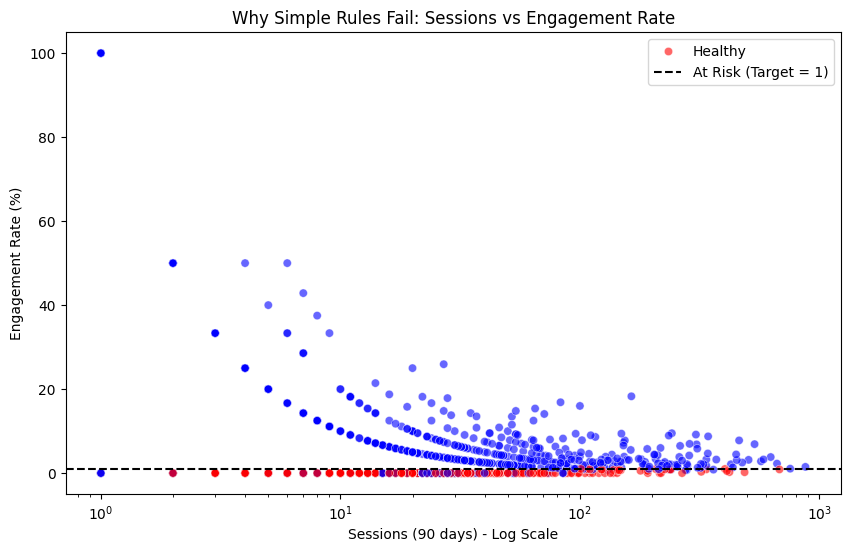

Observation: Notice how 'At Risk' (red) and 'Healthy' (blue) points bleed into each other. You cannot draw a single straight vertical or horizontal line to perfectly separate them. ML is needed to draw the complex boundary.


In [11]:
# 5. Visualize why a simple threshold fails
plt.figure(figsize=(10, 6))

# Plotting a sample to avoid overplotting
sample_df = df.dropna(subset=['sessions_90d', 'engagement_rate', 'target_needs_refresh']).sample(2000, random_state=42)

sns.scatterplot(
    data=sample_df,
    x='sessions_90d',
    y='engagement_rate',
    hue='target_needs_refresh',
    palette={0: 'blue', 1: 'red'},
    alpha=0.6
)

plt.title('Why Simple Rules Fail: Sessions vs Engagement Rate')
plt.xlabel('Sessions (90 days) - Log Scale')
plt.ylabel('Engagement Rate (%)')
plt.xscale('log')
plt.axhline(1.0, color='black', linestyle='--', label='1% Engagement Rule')

# Customizing legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles[1:], labels=['Healthy', 'At Risk (Target = 1)', '1% Threshold'])

plt.show()

print("Observation: Notice how 'At Risk' (red) and 'Healthy' (blue) points bleed into each other. You cannot draw a single straight vertical or horizontal line to perfectly separate them. ML is needed to draw the complex boundary.")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.